In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("/Users/jamesemcnally/Dropbox/DSBC Student Risk Factors Datasets/merged_streaming_data.csv")

In [4]:
pd.set_option('display.max_columns', 50)
df.describe().round(2)

,id_student,date,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,id_assessment,is_banked,score,due_date,weight,module_presentation_length,num_of_prev_attempts,studied_credits,date_registration,date_unregistration
count,1875496.00,1875496.00,1875496.00,1875496.00,1875496.00,1875496.00,1875496.00,1875496.00,1875496.00,1875496.00,1875496.00,1814206.00,1875496.00,1875496.00,1875496.00,1875496.00,1875496.00,1875496.00,1875496.00,1875496.0,1875496.00,1875496.0,173912.00,173912.00,173739.0,171047.00,173912.00,1875496.00,1875496.00,1875496.00,1875393.00,169346.00
mean,725399.86,100.54,4.26,3.72,6.03,1.83,0.30,0.59,0.05,0.03,0.06,3.90,0.02,0.00,0.03,0.03,0.03,0.48,0.01,0.0,0.00,0.0,26553.80,0.01,75.8,130.61,12.74,256.54,0.12,77.38,-69.13,126.02
std,574977.68,75.41,9.65,7.49,15.42,4.97,1.01,7.07,0.95,0.61,0.53,21.39,0.46,0.01,0.44,0.31,0.37,4.12,0.21,0.0,0.06,0.1,8829.78,0.10,18.8,78.03,17.88,13.11,0.41,37.07,47.94,65.94
min,6516.00,-25.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,1752.00,0.00,0.0,12.00,0.00,234.00,0.00,30.00,-312.00,-365.00
25%,506020.00,32.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,15022.00,0.00,65.0,54.00,0.00,241.00,0.00,60.00,-99.00,75.00
50%,588261.00,94.00,0.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,25359.00,0.00,80.0,129.00,9.00,262.00,0.00,60.00,-57.00,132.00
75%,645369.00,161.00,5.00,5.00,6.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,34883.00,0.00,90.0,214.00,18.00,268.00,0.00,90.00,-29.00,174.00
max,2698588.00,608.00,1224.00,6977.00,3733.00,3967.00,360.00,4956.00,241.00,70.00,146.00,2623.00,118.00,5.00,25.00,44.00,332.00,581.00,39.00,4.0,7.00,31.0,37443.00,1.00,100.0,261.00,100.00,269.00,6.00,630.00,167.00,444.00


In [5]:
summary = pd.DataFrame({
    'Zero Count': (df == 0).sum(),
    'Non-Zero Count': (df != 0).sum(),
    'Total Non-Null': df.count()
})
summary['% Zero'] = (summary['Zero Count'] / summary['Total Non-Null'] * 100).round(2)
summary['% Non-Zero'] = (summary['Non-Zero Count'] / summary['Total Non-Null'] * 100).round(2)
print(summary)

                            Zero Count  Non-Zero Count  Total Non-Null  \
id_student                           0         1875496         1875496   
code_module                          0         1875496         1875496   
code_presentation                    0         1875496         1875496   
date                              9465         1866031         1875496   
forumng                        1050624          824872         1875496   
homepage                        134389         1741107         1875496   
oucontent                      1041912          833584         1875496   
subpage                        1066905          808591         1875496   
url                            1560597          314899         1875496   
resource                       1474165          401331         1875496   
glossary                       1858205           17291         1875496   
dataplus                       1868527            6969         1875496   
oucollaborate                  1828099

In [6]:
# Create a "week" column relative to each code_presentation's starting date. 
# Dates 0.0 - 6.0 are week 1, 7.0 - 13.0 are week 2, etc. 
# The weeks *before* date 0.0 are assigned to negative values. 

df['week'] = df.groupby('code_presentation')['date'].transform(
    lambda x: ((x // 7) + 1).where(x >= 0, x // 7)
)
df.head(10)

,id_student,code_module,code_presentation,date,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,id_assessment,is_banked,score,assessment_type,due_date,weight,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,week
0,6516,AAA,2014J,-23.0,0,3,23,2,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-4.0
1,6516,AAA,2014J,-22.0,33,13,34,0,0,2,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-4.0
2,6516,AAA,2014J,-20.0,13,12,8,1,0,7,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-3.0
3,6516,AAA,2014J,-17.0,0,2,0,3,2,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-3.0
4,6516,AAA,2014J,-12.0,1,1,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-2.0
5,6516,AAA,2014J,-6.0,12,4,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-1.0
6,6516,AAA,2014J,-5.0,0,7,5,1,0,2,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-1.0
7,6516,AAA,2014J,-2.0,2,8,23,5,2,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-1.0
8,6516,AAA,2014J,-1.0,3,7,15,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-1.0
9,6516,AAA,2014J,0.0,48,11,1,5,6,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,1.0


In [7]:
# Creates a new column, "total_vle_interactions", that sums all the total VLE interactions on a given day irrespective of type.

vle_columns = [
    'forumng', 'homepage', 'oucontent', 'subpage', 'url', 'resource', 
    'glossary', 'dataplus', 'oucollaborate', 'quiz', 'ouelluminate', 
    'sharedsubpage', 'questionnaire', 'page', 'externalquiz', 'ouwiki', 
    'dualpane', 'repeatactivity', 'folder', 'htmlactivity'
]

# Sum across columns for each row
df['total_vle_interactions'] = df[vle_columns].sum(axis=1)

df.head(20)

,id_student,code_module,code_presentation,date,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,id_assessment,is_banked,score,assessment_type,due_date,weight,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,week,total_vle_interactions
0,6516,AAA,2014J,-23.0,0,3,23,2,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-4.0,28.0
1,6516,AAA,2014J,-22.0,33,13,34,0,0,2,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-4.0,82.0
2,6516,AAA,2014J,-20.0,13,12,8,1,0,7,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-3.0,41.0
3,6516,AAA,2014J,-17.0,0,2,0,3,2,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-3.0,7.0
4,6516,AAA,2014J,-12.0,1,1,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-2.0,2.0
5,6516,AAA,2014J,-6.0,12,4,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-1.0,16.0
6,6516,AAA,2014J,-5.0,0,7,5,1,0,2,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-1.0,15.0
7,6516,AAA,2014J,-2.0,2,8,23,5,2,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-1.0,40.0
8,6516,AAA,2014J,-1.0,3,7,15,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-1.0,25.0
9,6516,AAA,2014J,0.0,48,11,1,5,6,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,1.0,71.0


In [ ]:
# Tinkering with 3 types of features to measure "diversity"--i.e. diversity of types of interaction with the VLE.
# These features are per-day diversity of interactions
# NB: This code takes ~ 6-7 minutes to run

from scipy.stats import entropy

# Define VLE columns
vle_columns = [
    'forumng', 'homepage', 'oucontent', 'subpage', 'url', 'resource', 
    'glossary', 'dataplus', 'oucollaborate', 'quiz', 'ouelluminate', 
    'sharedsubpage', 'questionnaire', 'page', 'externalquiz', 'ouwiki', 
    'dualpane', 'repeatactivity', 'folder', 'htmlactivity'
]

# 1. VLE RICHNESS - Number of different VLE types used
# Range: 0-20 | Interpretation: Higher = used more types
df['vle_richness'] = (df[vle_columns] > 0).sum(axis=1)

# 2. SHANNON ENTROPY - Overall diversity of interactions
# Range: 0 to ~4.3 | Interpretation: Higher = more diverse/balanced
def shannon_entropy(row):
    counts = row[vle_columns].values.astype(float)
    counts = counts[counts > 0]
    if len(counts) == 0:
        return 0
    proportions = counts / counts.sum()
    return entropy(proportions, base=2)

df['diversity_shannon'] = df.apply(shannon_entropy, axis=1)

# 3. DOMINANCE - Proportion of interactions with most-used type
# Range: 0-1 | Interpretation: Higher = more focused on one type, Lower = more spread out
def dominance(row):
    counts = row[vle_columns].values.astype(float)
    total = counts.sum()
    if total == 0:
        return 0
    return counts.max() / total

df['dominance'] = df.apply(dominance, axis=1)


In [9]:
df.head()

,id_student,code_module,code_presentation,date,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,id_assessment,is_banked,score,assessment_type,due_date,weight,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,week,total_vle_interactions,vle_richness,diversity_shannon,dominance
0,6516,AAA,2014J,-23.0,0,3,23,2,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-4.0,28.0,3,0.850326,0.821429
1,6516,AAA,2014J,-22.0,33,13,34,0,0,2,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-4.0,82.0,4,1.607010,0.414634
2,6516,AAA,2014J,-20.0,13,12,8,1,0,7,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-3.0,41.0,5,2.070314,0.317073
3,6516,AAA,2014J,-17.0,0,2,0,3,2,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-3.0,7.0,3,1.556657,0.428571
4,6516,AAA,2014J,-12.0,1,1,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-2.0,2.0,2,1.000000,0.500000


In [11]:
# The above metric creates diversity per day. Below is code that generates diversity metrics per student per code presentation *for the entire module*
# The code both creates a new summary table, student_diversity, as well as adds the overall metric to the original dataframe, df.

from scipy.stats import entropy

# Define VLE columns
vle_columns = [
    'forumng', 'homepage', 'oucontent', 'subpage', 'url', 'resource', 
    'glossary', 'dataplus', 'oucollaborate', 'quiz', 'ouelluminate', 
    'sharedsubpage', 'questionnaire', 'page', 'externalquiz', 'ouwiki', 
    'dualpane', 'repeatactivity', 'folder', 'htmlactivity'
]

student_col = 'id_student' 

# Step 1: Aggregate all interactions per student per course_presentation
student_diversity = df.groupby([student_col, 'code_presentation'])[vle_columns].sum().reset_index()

# Step 2: Calculate diversity metrics for each student

# 2.1 VLE Richness - Number of different VLE types used overall
student_diversity['overall_vle_richness'] = (student_diversity[vle_columns] > 0).sum(axis=1)

# 2.2 Shannon Entropy - Overall diversity score
def shannon_entropy(row):
    counts = row[vle_columns].values.astype(float)
    counts = counts[counts > 0]
    if len(counts) == 0:
        return 0
    proportions = counts / counts.sum()
    return entropy(proportions, base=2)

student_diversity['overall_diversity_shannon'] = student_diversity.apply(shannon_entropy, axis=1)

# 2.3 Dominance - Proportion in most-used type
def dominance(row):
    counts = row[vle_columns].values.astype(float)
    total = counts.sum()
    if total == 0:
        return 0
    return counts.max() / total

student_diversity['overall_dominance'] = student_diversity.apply(dominance, axis=1)

# Step 3: Add final_result to this dataframe (assuming it's consistent per student)
final_results = df.groupby([student_col, 'code_presentation'])['final_result'].first().reset_index()
student_diversity = student_diversity.merge(final_results, on=[student_col, 'code_presentation'])

# Display results
print("OVERALL INTERACTION DIVERSITY PER STUDENT")
print("=" * 70)
print(f"\nTotal students analyzed: {len(student_diversity)}")
print("\nSample of student-level diversity metrics:")
print(student_diversity[[student_col, 'code_presentation', 'overall_vle_richness', 
                         'overall_diversity_shannon', 'overall_dominance', 'final_result']].head(10))

print("\nSummary Statistics:")
print(student_diversity[['overall_vle_richness', 'overall_diversity_shannon', 
                         'overall_dominance']].describe())

# Merge back to original dataframe for student-level metrics on every row
df = df.merge(student_diversity[[student_col, 'code_presentation', 'overall_vle_richness', 
                                  'overall_diversity_shannon', 'overall_dominance']], 
              on=[student_col, 'code_presentation'], 
              how='left')

print("\n✓ Overall diversity metrics added to original dataframe")
print("New columns: 'overall_vle_richness', 'overall_diversity_shannon', 'overall_dominance'")

OVERALL INTERACTION DIVERSITY PER STUDENT

Total students analyzed: 28425

Sample of student-level diversity metrics:
   id_student code_presentation  overall_vle_richness  \
0        6516             2014J                     7   
1        8462             2013J                     9   
2        8462             2014J                     3   
3       11391             2013J                     6   
4       23629             2013B                     5   
5       23698             2014J                     8   
6       23798             2013J                     9   
7       24186             2014B                     6   
8       24213             2014B                     9   
9       24391             2013J                     7   

   overall_diversity_shannon  overall_dominance final_result  
0                   1.913144           0.539233         Pass  
1                   2.485129           0.351393    Withdrawn  
2                   1.156780           0.700000    Withdrawn  
3 

In [12]:
df.head(5)

,id_student,code_module,code_presentation,date,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,id_assessment,is_banked,score,assessment_type,due_date,weight,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,week,total_vle_interactions,vle_richness,diversity_shannon,dominance,overall_vle_richness,overall_diversity_shannon,overall_dominance
0,6516,AAA,2014J,-23.0,0,3,23,2,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-4.0,28.0,3,0.850326,0.821429,7,1.913144,0.539233
1,6516,AAA,2014J,-22.0,33,13,34,0,0,2,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-4.0,82.0,4,1.607010,0.414634,7,1.913144,0.539233
2,6516,AAA,2014J,-20.0,13,12,8,1,0,7,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-3.0,41.0,5,2.070314,0.317073,7,1.913144,0.539233
3,6516,AAA,2014J,-17.0,0,2,0,3,2,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-3.0,7.0,3,1.556657,0.428571,7,1.913144,0.539233
4,6516,AAA,2014J,-12.0,1,1,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-2.0,2.0,2,1.000000,0.500000,7,1.913144,0.539233


In [13]:
student_diversity.head()

,id_student,code_presentation,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,overall_vle_richness,overall_diversity_shannon,overall_dominance,final_result
0,6516,2014J,451,497,1505,143,143,31,0,21,0,0.0,0,0,0,0,0,0,0,0,0,0,7,1.913144,0.539233,Pass
1,8462,2013J,36,184,64,227,23,70,0,0,12,0.0,0,0,0,0,12,18,0,0,0,0,9,2.485129,0.351393,Withdrawn
2,8462,2014J,2,7,0,0,0,0,0,0,1,0.0,0,0,0,0,0,0,0,0,0,0,3,1.156780,0.700000,Withdrawn
3,11391,2013J,193,138,553,32,5,13,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,6,1.618356,0.592077,Pass
4,23629,2013B,87,36,0,5,0,2,0,0,0,31.0,0,0,0,0,0,0,0,0,0,0,5,1.654873,0.540373,Fail


EXPLORING DIVERSITY AND STUDENT OUTCOMES

1. AVERAGE DIVERSITY BY FINAL RESULT
--------------------------------------------------------------------------------
             overall_vle_richness        overall_diversity_shannon         \
                             mean median                      mean median   
final_result                                                                
Distinction                  9.39    9.0                      2.14   2.19   
Fail                         7.46    7.0                      2.04   2.15   
Pass                         9.14    9.0                      2.16   2.21   
Withdrawn                    7.08    7.0                      1.99   2.13   

             overall_dominance         
                          mean median  
final_result                           
Distinction               0.45   0.43  
Fail                      0.44   0.41  
Pass                      0.43   0.41  
Withdrawn                 0.45   0.41  


/var/folders/1v/h2vyfq9j45n9_tmm_gg2s8tm0000gn/T/ipykernel_64931/940859074.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=student_diversity, x='final_result', y='overall_vle_richness',
/var/folders/1v/h2vyfq9j45n9_tmm_gg2s8tm0000gn/T/ipykernel_64931/940859074.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=student_diversity, x='final_result', y='overall_diversity_shannon',
/var/folders/1v/h2vyfq9j45n9_tmm_gg2s8tm0000gn/T/ipykernel_64931/940859074.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=student_diversity

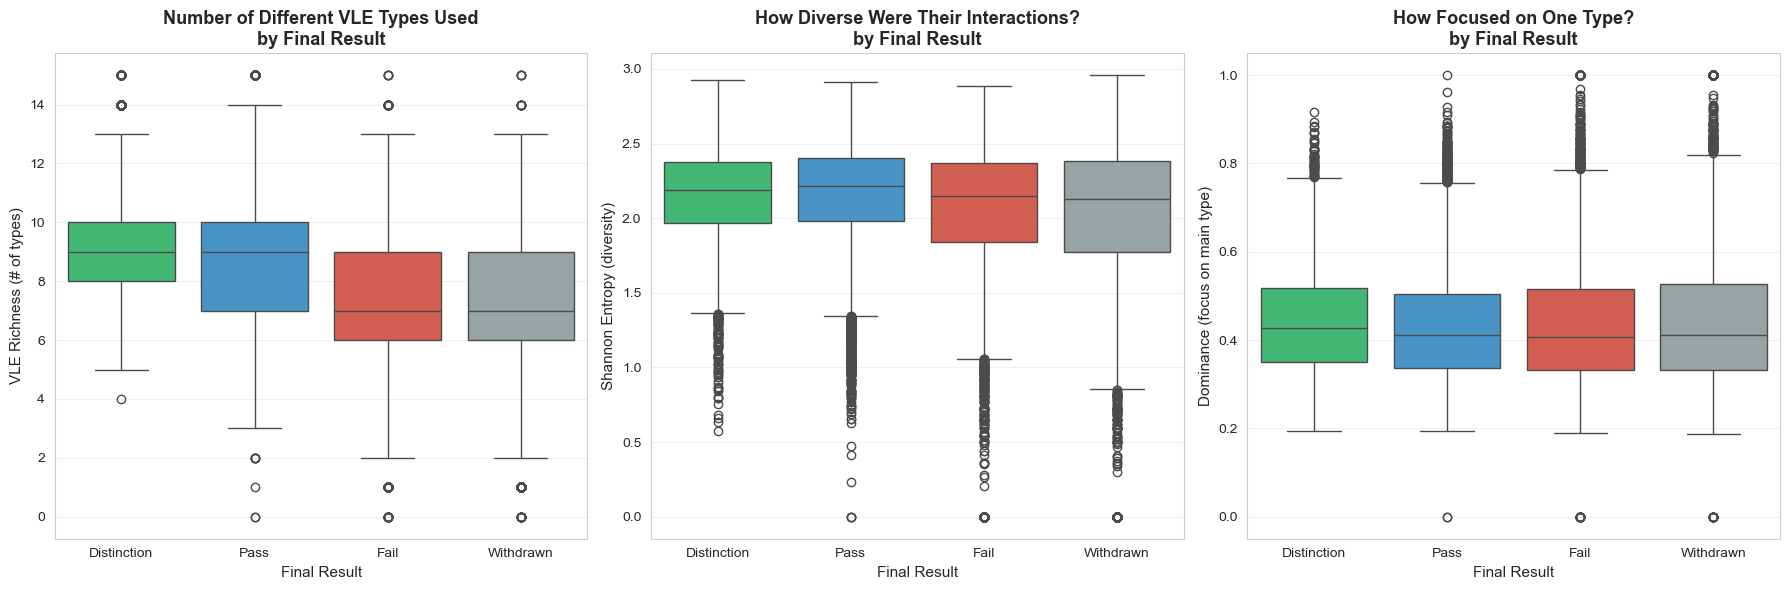


2. ARE THESE DIFFERENCES STATISTICALLY SIGNIFICANT?
--------------------------------------------------------------------------------

VLE Richness (# of types used):
  • Statistical test p-value: 0.0000
  • Result: YES - VERY STRONG relationship (p < 0.001) ***
  • Strength: 14.0% of variation explained by outcome

Shannon Entropy (diversity score):
  • Statistical test p-value: 0.0000
  • Result: YES - VERY STRONG relationship (p < 0.001) ***
  • Strength: 2.6% of variation explained by outcome

Dominance (focus on one type):
  • Statistical test p-value: 0.0000
  • Result: YES - VERY STRONG relationship (p < 0.001) ***
  • Strength: 0.3% of variation explained by outcome

3. KEY TAKEAWAYS - WHAT DOES THIS MEAN?

📊 VLE RICHNESS (Number of different types used):
   Distinction students used an average of 9.4 types
   Withdrawn students used an average of 7.1 types
   → Success is associated with exploring MORE different VLE types

📊 SHANNON ENTROPY (How diverse/balanced interactions w

In [15]:
# Exploring the relationship between the three overall diversity of interaction metrics and final_result using the student_diversity table

from scipy import stats
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

print("=" * 80)
print("EXPLORING DIVERSITY AND STUDENT OUTCOMES")
print("=" * 80)

# 1. SIMPLE SUMMARY: Average values by outcome
print("\n1. AVERAGE DIVERSITY BY FINAL RESULT")
print("-" * 80)

summary = student_diversity.groupby('final_result')[
    ['overall_vle_richness', 'overall_diversity_shannon', 'overall_dominance']
].agg(['mean', 'median']).round(2)

print(summary)

# 2. VISUALIZATIONS - Box plots (easy to read)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

result_order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']

# Plot 1: VLE Richness
sns.boxplot(data=student_diversity, x='final_result', y='overall_vle_richness',
            order=result_order, palette=colors, ax=axes[0])
axes[0].set_title('Number of Different VLE Types Used\nby Final Result', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Final Result', fontsize=11)
axes[0].set_ylabel('VLE Richness (# of types)', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Shannon Entropy
sns.boxplot(data=student_diversity, x='final_result', y='overall_diversity_shannon',
            order=result_order, palette=colors, ax=axes[1])
axes[1].set_title('How Diverse Were Their Interactions?\nby Final Result', 
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Final Result', fontsize=11)
axes[1].set_ylabel('Shannon Entropy (diversity)', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

# Plot 3: Dominance
sns.boxplot(data=student_diversity, x='final_result', y='overall_dominance',
            order=result_order, palette=colors, ax=axes[2])
axes[2].set_title('How Focused on One Type?\nby Final Result', 
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Final Result', fontsize=11)
axes[2].set_ylabel('Dominance (focus on main type)', fontsize=11)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 3. SIMPLE STATISTICAL TEST - Is there a real difference?
print("\n2. ARE THESE DIFFERENCES STATISTICALLY SIGNIFICANT?")
print("-" * 80)

metrics = {
    'overall_vle_richness': 'VLE Richness (# of types used)',
    'overall_diversity_shannon': 'Shannon Entropy (diversity score)',
    'overall_dominance': 'Dominance (focus on one type)'
}

for metric_col, metric_name in metrics.items():
    # Get data for each outcome group
    distinction = student_diversity[student_diversity['final_result'] == 'Distinction'][metric_col].dropna()
    pass_group = student_diversity[student_diversity['final_result'] == 'Pass'][metric_col].dropna()
    fail = student_diversity[student_diversity['final_result'] == 'Fail'][metric_col].dropna()
    withdrawn = student_diversity[student_diversity['final_result'] == 'Withdrawn'][metric_col].dropna()
    
    # Statistical test
    f_stat, p_value = stats.f_oneway(distinction, pass_group, fail, withdrawn)
    
    # Calculate effect size (how much does outcome explain the metric?)
    all_data = pd.concat([distinction, pass_group, fail, withdrawn])
    grand_mean = all_data.mean()
    
    ss_between = (len(distinction) * (distinction.mean() - grand_mean)**2 +
                  len(pass_group) * (pass_group.mean() - grand_mean)**2 +
                  len(fail) * (fail.mean() - grand_mean)**2 +
                  len(withdrawn) * (withdrawn.mean() - grand_mean)**2)
    
    ss_total = ((all_data - grand_mean)**2).sum()
    eta_squared = ss_between / ss_total if ss_total > 0 else 0
    
    print(f"\n{metric_name}:")
    print(f"  • Statistical test p-value: {p_value:.4f}")
    
    if p_value < 0.001:
        print(f"  • Result: YES - VERY STRONG relationship (p < 0.001) ***")
    elif p_value < 0.01:
        print(f"  • Result: YES - Strong relationship (p < 0.01) **")
    elif p_value < 0.05:
        print(f"  • Result: YES - Significant relationship (p < 0.05) *")
    else:
        print(f"  • Result: NO - No significant relationship (p ≥ 0.05)")
    
    print(f"  • Strength: {eta_squared*100:.1f}% of variation explained by outcome")

# 4. KEY TAKEAWAYS
print("\n" + "=" * 80)
print("3. KEY TAKEAWAYS - WHAT DOES THIS MEAN?")
print("=" * 80)

# Calculate means for interpretation
means = student_diversity.groupby('final_result')[
    ['overall_vle_richness', 'overall_diversity_shannon', 'overall_dominance']
].mean()

print("\n📊 VLE RICHNESS (Number of different types used):")
print(f"   Distinction students used an average of {means.loc['Distinction', 'overall_vle_richness']:.1f} types")
print(f"   Withdrawn students used an average of {means.loc['Withdrawn', 'overall_vle_richness']:.1f} types")
if means.loc['Distinction', 'overall_vle_richness'] > means.loc['Withdrawn', 'overall_vle_richness']:
    print("   → Success is associated with exploring MORE different VLE types")
else:
    print("   → Success is associated with exploring FEWER different VLE types")

print("\n📊 SHANNON ENTROPY (How diverse/balanced interactions were):")
print(f"   Distinction students: {means.loc['Distinction', 'overall_diversity_shannon']:.2f}")
print(f"   Withdrawn students: {means.loc['Withdrawn', 'overall_diversity_shannon']:.2f}")
if means.loc['Distinction', 'overall_diversity_shannon'] > means.loc['Withdrawn', 'overall_diversity_shannon']:
    print("   → Success is associated with MORE diverse interaction patterns")
else:
    print("   → Success is associated with LESS diverse interaction patterns")

print("\n📊 DOMINANCE (Focus on single type):")
print(f"   Distinction students: {means.loc['Distinction', 'overall_dominance']:.2f} (focus level)")
print(f"   Withdrawn students: {means.loc['Withdrawn', 'overall_dominance']:.2f} (focus level)")
if means.loc['Distinction', 'overall_dominance'] < means.loc['Withdrawn', 'overall_dominance']:
    print("   → Success is associated with SPREADING interactions across types")
else:
    print("   → Success is associated with FOCUSING on fewer types")

print("\n" + "=" * 80)

Below I start to tinker with feature engineering new columns that measure regularity. The code below generates *overall* regularity metrics per id_student, not per week. 

In [18]:
# Calculate total coeffient of variation for each student over the course of the module
# NB: this is overall, not week by week

def calculate_regularity_cv(df, student_id_col='id_student', date_col='date'):
    def cv_gaps(x):
        gaps = x.sort_values().diff().dropna()
        if len(gaps) == 0 or gaps.mean() == 0:
            return np.nan
        return gaps.std() / gaps.mean()
    
    cv_scores = df.groupby(student_id_col)[date_col].apply(cv_gaps)
    df['cv_regularity_overall'] = df[student_id_col].map(cv_scores)
    return df

# Lower CV = more regular
# Higher CV = more variable/intermittent
df = calculate_regularity_cv(df)

In [19]:
df.head()

,id_student,code_module,code_presentation,date,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,id_assessment,...,score,assessment_type,due_date,weight,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,week,total_vle_interactions,vle_richness,diversity_shannon,dominance,overall_vle_richness,overall_diversity_shannon,overall_dominance,cv_regularity_overall
0,6516,AAA,2014J,-23.0,0,3,23,2,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,...,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-4.0,28.0,3,0.850326,0.821429,7,1.913144,0.539233,1.320019
1,6516,AAA,2014J,-22.0,33,13,34,0,0,2,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,...,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-4.0,82.0,4,1.607010,0.414634,7,1.913144,0.539233,1.320019
2,6516,AAA,2014J,-20.0,13,12,8,1,0,7,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,...,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-3.0,41.0,5,2.070314,0.317073,7,1.913144,0.539233,1.320019
3,6516,AAA,2014J,-17.0,0,2,0,3,2,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,...,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-3.0,7.0,3,1.556657,0.428571,7,1.913144,0.539233,1.320019
4,6516,AAA,2014J,-12.0,1,1,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,...,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-2.0,2.0,2,1.000000,0.500000,7,1.913144,0.539233,1.320019


In [20]:
# Exports regularity metric above to student_diversity so we have 1 row per student

cv_per_student = df.groupby(['id_student', 'code_presentation'])['cv_regularity_overall'].first().reset_index()

student_diversity = student_diversity.merge(
    cv_per_student,
    on=['id_student', 'code_presentation'],
    how='left'
)

print("✓ cv_regularity_overall added to student_diversity")

✓ cv_regularity_overall added to student_diversity


In [22]:
student_diversity.head()

,id_student,code_presentation,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,overall_vle_richness,overall_diversity_shannon,overall_dominance,final_result,cv_regularity_overall
0,6516,2014J,451,497,1505,143,143,31,0,21,0,0.0,0,0,0,0,0,0,0,0,0,0,7,1.913144,0.539233,Pass,1.320019
1,8462,2013J,36,184,64,227,23,70,0,0,12,0.0,0,0,0,0,12,18,0,0,0,0,9,2.485129,0.351393,Withdrawn,1.038425
2,8462,2014J,2,7,0,0,0,0,0,0,1,0.0,0,0,0,0,0,0,0,0,0,0,3,1.156780,0.700000,Withdrawn,1.038425
3,11391,2013J,193,138,553,32,5,13,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,6,1.618356,0.592077,Pass,0.829739
4,23629,2013B,87,36,0,5,0,2,0,0,0,31.0,0,0,0,0,0,0,0,0,0,0,5,1.654873,0.540373,Fail,0.756187


In [26]:
# Calculate total standard deviation of gaps for each student over the course of the module
# NB: this is overall, not week by week

def calculate_regularity_std(df, student_id_col='id_student', date_col='date'):
    regularity = df.groupby(student_id_col)[date_col].apply(
        lambda x: x.sort_values().diff().std()
    )
    # Add as a new column to the dataframe
    df['std_regularity_overall'] = df[student_id_col].map(regularity)
    return df

# Lower values = more regular logins
# Higher values = more intermittent/irregular
df = calculate_regularity_std(df)

In [27]:
df.head()

,id_student,code_module,code_presentation,date,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,id_assessment,...,assessment_type,due_date,weight,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,week,total_vle_interactions,vle_richness,diversity_shannon,dominance,overall_vle_richness,overall_diversity_shannon,overall_dominance,cv_regularity_overall,std_regularity_overall
0,6516,AAA,2014J,-23.0,0,3,23,2,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,...,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-4.0,28.0,3,0.850326,0.821429,7,1.913144,0.539233,1.320019,2.439529
1,6516,AAA,2014J,-22.0,33,13,34,0,0,2,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,...,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-4.0,82.0,4,1.607010,0.414634,7,1.913144,0.539233,1.320019,2.439529
2,6516,AAA,2014J,-20.0,13,12,8,1,0,7,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,...,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-3.0,41.0,5,2.070314,0.317073,7,1.913144,0.539233,1.320019,2.439529
3,6516,AAA,2014J,-17.0,0,2,0,3,2,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,...,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-3.0,7.0,3,1.556657,0.428571,7,1.913144,0.539233,1.320019,2.439529
4,6516,AAA,2014J,-12.0,1,1,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,...,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-2.0,2.0,2,1.000000,0.500000,7,1.913144,0.539233,1.320019,2.439529


In [28]:
# Extract std_regularity_overall to student_diversity
std_per_student = df.groupby(['id_student', 'code_presentation'])['std_regularity_overall'].first().reset_index()

student_diversity = student_diversity.merge(
    std_per_student,
    on=['id_student', 'code_presentation'],
    how='left'
)

print("✓ std_regularity_overall added to student_diversity")

✓ std_regularity_overall added to student_diversity


In [33]:
student_diversity.head()

,id_student,code_presentation,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,overall_vle_richness,overall_diversity_shannon,overall_dominance,final_result,cv_regularity_overall,std_regularity_overall_x
0,6516,2014J,451,497,1505,143,143,31,0,21,0,0.0,0,0,0,0,0,0,0,0,0,0,7,1.913144,0.539233,Pass,1.320019,2.439529
1,8462,2013J,36,184,64,227,23,70,0,0,12,0.0,0,0,0,0,12,18,0,0,0,0,9,2.485129,0.351393,Withdrawn,1.038425,2.146078
2,8462,2014J,2,7,0,0,0,0,0,0,1,0.0,0,0,0,0,0,0,0,0,0,0,3,1.156780,0.700000,Withdrawn,1.038425,2.146078
3,11391,2013J,193,138,553,32,5,13,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,6,1.618356,0.592077,Pass,0.829739,5.096969
4,23629,2013B,87,36,0,5,0,2,0,0,0,31.0,0,0,0,0,0,0,0,0,0,0,5,1.654873,0.540373,Fail,0.756187,4.492641


In [34]:
# Calculate how many days/week each student logs in over the course of the module
# Metric is "Active days per week"
# NB: this is overall, not week by week

def weekly_consistency(df, student_id_col='id_student', date_col='date', week_col='week'):
    """
    Calculate how consistently they log in each week.
    Adds 'active_days_per_week_overall' column to dataframe.
    """
    # Count unique days per week
    weekly_days = df.groupby([student_id_col, week_col])[date_col].nunique()
    
    # Calculate std of days per week (lower = more consistent)
    consistency = weekly_days.groupby(student_id_col).std()
    
    # Add as a new column to the dataframe
    df['active_days_per_week_overall'] = df[student_id_col].map(consistency)
    
    return df

# Lower values = more consistent weekly activity
# Higher values = more variable weekly activity
df = weekly_consistency(df)


In [36]:
df.head()

,id_student,code_module,code_presentation,date,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,id_assessment,...,due_date,weight,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,week,total_vle_interactions,vle_richness,diversity_shannon,dominance,overall_vle_richness,overall_diversity_shannon,overall_dominance,cv_regularity_overall,std_regularity_overall,active_days_per_week_overall
0,6516,AAA,2014J,-23.0,0,3,23,2,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,...,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-4.0,28.0,3,0.850326,0.821429,7,1.913144,0.539233,1.320019,2.439529,1.628442
1,6516,AAA,2014J,-22.0,33,13,34,0,0,2,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,...,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-4.0,82.0,4,1.607010,0.414634,7,1.913144,0.539233,1.320019,2.439529,1.628442
2,6516,AAA,2014J,-20.0,13,12,8,1,0,7,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,...,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-3.0,41.0,5,2.070314,0.317073,7,1.913144,0.539233,1.320019,2.439529,1.628442
3,6516,AAA,2014J,-17.0,0,2,0,3,2,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,...,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-3.0,7.0,3,1.556657,0.428571,7,1.913144,0.539233,1.320019,2.439529,1.628442
4,6516,AAA,2014J,-12.0,1,1,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,...,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-2.0,2.0,2,1.000000,0.500000,7,1.913144,0.539233,1.320019,2.439529,1.628442


In [35]:
# Extract active_days_per_week_overall to student_diversity
weekly_consistency_per_student = df.groupby(['id_student', 'code_presentation'])['active_days_per_week_overall'].first().reset_index()

student_diversity = student_diversity.merge(
    weekly_consistency_per_student,
    on=['id_student', 'code_presentation'],
    how='left'
)

print("✓ active_days_per_week_overall added to student_diversity")

student_diversity.head()

✓ active_days_per_week_overall added to student_diversity


,id_student,code_presentation,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,overall_vle_richness,overall_diversity_shannon,overall_dominance,final_result,cv_regularity_overall,std_regularity_overall_x,active_days_per_week_overall
0,6516,2014J,451,497,1505,143,143,31,0,21,0,0.0,0,0,0,0,0,0,0,0,0,0,7,1.913144,0.539233,Pass,1.320019,2.439529,1.628442
1,8462,2013J,36,184,64,227,23,70,0,0,12,0.0,0,0,0,0,12,18,0,0,0,0,9,2.485129,0.351393,Withdrawn,1.038425,2.146078,1.263166
2,8462,2014J,2,7,0,0,0,0,0,0,1,0.0,0,0,0,0,0,0,0,0,0,0,3,1.156780,0.700000,Withdrawn,1.038425,2.146078,1.263166
3,11391,2013J,193,138,553,32,5,13,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,6,1.618356,0.592077,Pass,0.829739,5.096969,0.784706
4,23629,2013B,87,36,0,5,0,2,0,0,0,31.0,0,0,0,0,0,0,0,0,0,0,5,1.654873,0.540373,Fail,0.756187,4.492641,0.797724


Now I'm experimenting with various other features.

First, three features that categorize the different types of features into three categories: (a) assessment, (b) content, and (c) collaborative. (Overall for the course). The returned metrics are percentages expressed as decimals.

In [37]:
from scipy.stats import linregress

vle_columns = [
    'forumng', 'homepage', 'oucontent', 'subpage', 'url', 'resource',
    'glossary', 'dataplus', 'oucollaborate', 'quiz', 'ouelluminate',
    'sharedsubpage', 'questionnaire', 'page', 'externalquiz', 'ouwiki',
    'dualpane', 'repeatactivity', 'folder', 'htmlactivity'
]

# Categorize VLE types
assessment_types = ['quiz', 'questionnaire', 'externalquiz']
content_types = ['oucontent', 'page', 'resource', 'url', 'homepage']
collaborative_types = ['forumng', 'oucollaborate', 'ouelluminate', 'ouwiki']

student_totals = df.groupby(['id_student', 'code_presentation'])[vle_columns].sum()

# Assessment focus
assessment_focus = student_totals[assessment_types].sum(axis=1) / student_totals[vle_columns].sum(axis=1)
assessment_focus = assessment_focus.fillna(0).rename('assessment_focus_ratio')

# Content focus
content_focus = student_totals[content_types].sum(axis=1) / student_totals[vle_columns].sum(axis=1)
content_focus = content_focus.fillna(0).rename('content_focus_ratio')

# Collaborative focus
collaborative_focus = student_totals[collaborative_types].sum(axis=1) / student_totals[vle_columns].sum(axis=1)
collaborative_focus = collaborative_focus.fillna(0).rename('collaborative_focus_ratio')

# Add to df (original behavior)
df = df.merge(assessment_focus, on=['id_student', 'code_presentation'], how='left')
df = df.merge(content_focus, on=['id_student', 'code_presentation'], how='left')
df = df.merge(collaborative_focus, on=['id_student', 'code_presentation'], how='left')

df.head()


,id_student,code_module,code_presentation,date,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,id_assessment,...,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,week,total_vle_interactions,vle_richness,diversity_shannon,dominance,overall_vle_richness,overall_diversity_shannon,overall_dominance,cv_regularity_overall,std_regularity_overall,active_days_per_week_overall,assessment_focus_ratio,content_focus_ratio,collaborative_focus_ratio
0,6516,AAA,2014J,-23.0,0,3,23,2,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,...,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-4.0,28.0,3,0.850326,0.821429,7,1.913144,0.539233,1.320019,2.439529,1.628442,0.0,0.779649,0.161591
1,6516,AAA,2014J,-22.0,33,13,34,0,0,2,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,...,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-4.0,82.0,4,1.607010,0.414634,7,1.913144,0.539233,1.320019,2.439529,1.628442,0.0,0.779649,0.161591
2,6516,AAA,2014J,-20.0,13,12,8,1,0,7,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,...,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-3.0,41.0,5,2.070314,0.317073,7,1.913144,0.539233,1.320019,2.439529,1.628442,0.0,0.779649,0.161591
3,6516,AAA,2014J,-17.0,0,2,0,3,2,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,...,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-3.0,7.0,3,1.556657,0.428571,7,1.913144,0.539233,1.320019,2.439529,1.628442,0.0,0.779649,0.161591
4,6516,AAA,2014J,-12.0,1,1,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,...,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,-2.0,2.0,2,1.000000,0.500000,7,1.913144,0.539233,1.320019,2.439529,1.628442,0.0,0.779649,0.161591


In [38]:
# ALSO add to student_diversity
student_diversity = student_diversity.merge(
    assessment_focus, 
    left_on=['id_student', 'code_presentation'],
    right_index=True, 
    how='left'
)

student_diversity = student_diversity.merge(
    content_focus, 
    left_on=['id_student', 'code_presentation'],
    right_index=True, 
    how='left'
)

student_diversity = student_diversity.merge(
    collaborative_focus, 
    left_on=['id_student', 'code_presentation'],
    right_index=True, 
    how='left'
)

# Fill any NaN values
student_diversity['assessment_focus_ratio'] = student_diversity['assessment_focus_ratio'].fillna(0)
student_diversity['content_focus_ratio'] = student_diversity['content_focus_ratio'].fillna(0)
student_diversity['collaborative_focus_ratio'] = student_diversity['collaborative_focus_ratio'].fillna(0)

In [39]:
student_diversity.head(10)

,id_student,code_presentation,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,overall_vle_richness,overall_diversity_shannon,overall_dominance,final_result,cv_regularity_overall,std_regularity_overall_x,active_days_per_week_overall,assessment_focus_ratio,content_focus_ratio,collaborative_focus_ratio
0,6516,2014J,451,497,1505,143,143,31,0,21,0,0.0,0,0,0,0,0,0,0,0,0,0,7,1.913144,0.539233,Pass,1.320019,2.439529,1.628442,0.000000,0.779649,0.161591
1,8462,2013J,36,184,64,227,23,70,0,0,12,0.0,0,0,0,0,12,18,0,0,0,0,9,2.485129,0.351393,Withdrawn,1.038425,2.146078,1.263166,0.018576,0.527864,0.102167
2,8462,2014J,2,7,0,0,0,0,0,0,1,0.0,0,0,0,0,0,0,0,0,0,0,3,1.156780,0.700000,Withdrawn,1.038425,2.146078,1.263166,0.000000,0.700000,0.300000
3,11391,2013J,193,138,553,32,5,13,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,6,1.618356,0.592077,Pass,0.829739,5.096969,0.784706,0.000000,0.759101,0.206638
4,23629,2013B,87,36,0,5,0,2,0,0,0,31.0,0,0,0,0,0,0,0,0,0,0,5,1.654873,0.540373,Fail,0.756187,4.492641,0.797724,0.192547,0.236025,0.540373
5,23698,2014J,63,121,4,98,5,42,0,0,0,576.0,0,0,0,1,0,0,0,0,0,0,8,1.708891,0.632967,Pass,1.295140,4.630568,1.638514,0.632967,0.190110,0.069231
6,23798,2013J,145,169,44,47,56,21,1,0,3,104.0,0,0,0,0,0,0,0,0,0,0,9,2.573779,0.286441,Distinction,1.027159,3.615065,1.087934,0.176271,0.491525,0.250847
7,24186,2014B,14,46,9,5,0,8,0,0,0,102.0,0,0,0,0,0,0,0,0,0,0,6,1.805556,0.554348,Pass,1.208750,10.533394,0.615699,0.554348,0.342391,0.076087
8,24213,2014B,778,325,262,427,26,51,0,0,26,0.0,0,0,0,0,9,88,0,0,0,0,9,2.350506,0.390562,Pass,0.906607,1.905412,1.769014,0.004518,0.333333,0.447791
9,24391,2013J,62,130,357,23,0,18,2,0,0,120.0,0,0,0,0,0,0,0,0,0,0,7,2.004839,0.501404,Distinction,0.940841,3.748188,0.966683,0.168539,0.709270,0.087079


In [ ]:
# Filter to week 1 data only
week1_data = df[df['week'] == 1].copy()

# Aggregate week 1 data per student - calculate averages
week_one = week1_data.groupby(['id_student', 'code_presentation']).agg({
    'total_vle_interactions': 'mean',  # Average daily interactions in week 1
    'vle_richness': 'mean',            # Average daily richness in week 1
    'diversity_shannon': 'mean',       # Average daily diversity in week 1
    'dominance': 'mean'                # Average daily dominance in week 1
}).reset_index()

# Rename columns to add _w1 suffix
week_one = week_one.rename(columns={
    'total_vle_interactions': 'total_vle_interactions_w1',
    'vle_richness': 'vle_richness_w1',
    'diversity_shannon': 'diversity_shannon_w1',
    'dominance': 'dominance_w1'
})

# Add final_result
final_results = df.groupby(['id_student', 'code_presentation'])['final_result'].first().reset_index()
week_one = week_one.merge(final_results, on=['id_student', 'code_presentation'], how='left')

week_one.head()


✓ week_one table created with 23081 students
✓ Columns: 7

Column names:
['id_student', 'code_presentation', 'total_vle_interactions_w1', 'vle_richness_w1', 'diversity_shannon_w1', 'dominance_w1', 'final_result']

Sample of week_one data:
   id_student code_presentation  total_vle_interactions_w1  vle_richness_w1  \
0        6516             2014J                  38.166667         3.833333   
1        8462             2013J                  16.200000         3.600000   
2       11391             2013J                  45.750000         3.500000   
3       23629             2013B                  11.500000         3.000000   
4       23698             2014J                   6.250000         1.750000   
5       23798             2013J                   4.000000         3.000000   
6       24186             2014B                   2.000000         2.000000   
7       24213             2014B                  31.428571         3.000000   
8       24391             2013J                  

In [42]:
week_one.head()

,id_student,code_presentation,total_vle_interactions_w1,vle_richness_w1,diversity_shannon_w1,dominance_w1,final_result
0,6516,2014J,38.166667,3.833333,1.464271,0.577427,Pass
1,8462,2013J,16.200000,3.600000,1.342197,0.575910,Withdrawn
2,11391,2013J,45.750000,3.500000,1.151643,0.662097,Pass
3,23629,2013B,11.500000,3.000000,1.313663,0.567460,Fail
4,23698,2014J,6.250000,1.750000,0.496365,0.848684,Pass


In [ ]:
# Now adding regularity metrics *for week 1 only* to the week_one table

#NB: I am assigning null values to zero. That may be the wrong move.

# Filter to week 1 data with actual interactions
week1_active = df[(df['week'] == 1) & (df['total_vle_interactions'] > 0)].copy()

# 1. CV Regularity for Week 1
def cv_gaps_w1(x):
    """Calculate coefficient of variation of login gaps in week 1"""
    gaps = x.sort_values().diff().dropna()
    if len(gaps) == 0 or gaps.mean() == 0:
        return np.nan
    return gaps.std() / gaps.mean()

cv_regularity_w1 = week1_active.groupby(['id_student', 'code_presentation'])['date'].apply(cv_gaps_w1).reset_index()
cv_regularity_w1.columns = ['id_student', 'code_presentation', 'cv_regularity_w1']

# 2. STD Regularity for Week 1
def std_gaps_w1(x):
    """Calculate standard deviation of login gaps in week 1"""
    gaps = x.sort_values().diff()
    return gaps.std()

std_regularity_w1 = week1_active.groupby(['id_student', 'code_presentation'])['date'].apply(std_gaps_w1).reset_index()
std_regularity_w1.columns = ['id_student', 'code_presentation', 'std_regularity_w1']

# 3. Active Days in Week 1
active_days_w1 = week1_active.groupby(['id_student', 'code_presentation'])['date'].nunique().reset_index()
active_days_w1.columns = ['id_student', 'code_presentation', 'active_days_w1']

# Merge all three metrics into week_one table
week_one = week_one.merge(cv_regularity_w1, on=['id_student', 'code_presentation'], how='left')
week_one = week_one.merge(std_regularity_w1, on=['id_student', 'code_presentation'], how='left')
week_one = week_one.merge(active_days_w1, on=['id_student', 'code_presentation'], how='left')

# Fill NaN values with 0 (students with no activity or insufficient data in week 1)
week_one['cv_regularity_w1'] = week_one['cv_regularity_w1'].fillna(0)
week_one['std_regularity_w1'] = week_one['std_regularity_w1'].fillna(0)
week_one['active_days_w1'] = week_one['active_days_w1'].fillna(0)

print("\n✓ Week 1 regularity metrics added to week_one table")
print(f"✓ New columns: cv_regularity_w1, std_regularity_w1, active_days_w1")

print("\nUpdated week_one columns:")
print(week_one.columns.tolist())


✓ Week 1 regularity metrics added to week_one table
✓ New columns: cv_regularity_w1, std_regularity_w1, active_days_w1

Updated week_one columns:
['id_student', 'code_presentation', 'total_vle_interactions_w1', 'vle_richness_w1', 'diversity_shannon_w1', 'dominance_w1', 'final_result', 'cv_regularity_w1', 'std_regularity_w1', 'active_days_w1']

Sample of week 1 regularity metrics:
   id_student code_presentation  cv_regularity_w1  std_regularity_w1  \
0        6516             2014J          0.372678           0.447214   
1        8462             2013J          0.384900           0.577350   
2       11391             2013J          0.866025           1.732051   
3       23629             2013B          0.000000           0.000000   
4       23698             2014J          0.500000           1.000000   
5       23798             2013J          0.000000           0.000000   
6       24186             2014B          0.000000           0.000000   
7       24213             2014B         

In [44]:
week_one.head()

,id_student,code_presentation,total_vle_interactions_w1,vle_richness_w1,diversity_shannon_w1,dominance_w1,final_result,cv_regularity_w1,std_regularity_w1,active_days_w1
0,6516,2014J,38.166667,3.833333,1.464271,0.577427,Pass,0.372678,0.447214,6.0
1,8462,2013J,16.200000,3.600000,1.342197,0.575910,Withdrawn,0.384900,0.577350,5.0
2,11391,2013J,45.750000,3.500000,1.151643,0.662097,Pass,0.866025,1.732051,4.0
3,23629,2013B,11.500000,3.000000,1.313663,0.567460,Fail,0.000000,0.000000,2.0
4,23698,2014J,6.250000,1.750000,0.496365,0.848684,Pass,0.500000,1.000000,4.0


In [ ]:
# Now adding regularity metrics *for week 1 only* to the week_one table

#NB: As in the previous code, I am assigning null values to zero. That, again, may be the wrong move.

# Define VLE columns and categories
vle_columns = [
    'forumng', 'homepage', 'oucontent', 'subpage', 'url', 'resource',
    'glossary', 'dataplus', 'oucollaborate', 'quiz', 'ouelluminate',
    'sharedsubpage', 'questionnaire', 'page', 'externalquiz', 'ouwiki',
    'dualpane', 'repeatactivity', 'folder', 'htmlactivity'
]

# Categorize VLE types
assessment_types = ['quiz', 'questionnaire', 'externalquiz']
content_types = ['oucontent', 'page', 'resource', 'url', 'homepage']
collaborative_types = ['forumng', 'oucollaborate', 'ouelluminate', 'ouwiki']

# NB: the following VLE types are not categorized under this metric: subpage, glossary, dataplus, sharedsubpage, dualpane, repeatactivity, folder, htmlactivity

# Filter to week 1 only and sum interactions per student
week1_vle_totals = df[df['week'] == 1].groupby(['id_student', 'code_presentation'])[vle_columns].sum()

# Calculate Assessment Focus for Week 1
assessment_focus_w1 = week1_vle_totals[assessment_types].sum(axis=1) / week1_vle_totals[vle_columns].sum(axis=1)
assessment_focus_w1 = assessment_focus_w1.fillna(0).reset_index()
assessment_focus_w1.columns = ['id_student', 'code_presentation', 'assessment_focus_ratio_w1']

# Calculate Content Focus for Week 1
content_focus_w1 = week1_vle_totals[content_types].sum(axis=1) / week1_vle_totals[vle_columns].sum(axis=1)
content_focus_w1 = content_focus_w1.fillna(0).reset_index()
content_focus_w1.columns = ['id_student', 'code_presentation', 'content_focus_ratio_w1']

# Calculate Collaborative Focus for Week 1
collaborative_focus_w1 = week1_vle_totals[collaborative_types].sum(axis=1) / week1_vle_totals[vle_columns].sum(axis=1)
collaborative_focus_w1 = collaborative_focus_w1.fillna(0).reset_index()
collaborative_focus_w1.columns = ['id_student', 'code_presentation', 'collaborative_focus_ratio_w1']

# Merge all three focus ratios into week_one table
week_one = week_one.merge(assessment_focus_w1, on=['id_student', 'code_presentation'], how='left')
week_one = week_one.merge(content_focus_w1, on=['id_student', 'code_presentation'], how='left')
week_one = week_one.merge(collaborative_focus_w1, on=['id_student', 'code_presentation'], how='left')

# Fill NaN values with 0 (students with no week 1 activity)
week_one['assessment_focus_ratio_w1'] = week_one['assessment_focus_ratio_w1'].fillna(0)
week_one['content_focus_ratio_w1'] = week_one['content_focus_ratio_w1'].fillna(0)
week_one['collaborative_focus_ratio_w1'] = week_one['collaborative_focus_ratio_w1'].fillna(0)

print("\n✓ Week 1 focus ratios added to week_one table")
print(f"✓ New columns: assessment_focus_ratio_w1, content_focus_ratio_w1, collaborative_focus_ratio_w1")

print("\nUpdated week_one columns:")
print(week_one.columns.tolist())


✓ Week 1 focus ratios added to week_one table
✓ New columns: assessment_focus_ratio_w1, content_focus_ratio_w1, collaborative_focus_ratio_w1

Updated week_one columns:
['id_student', 'code_presentation', 'total_vle_interactions_w1', 'vle_richness_w1', 'diversity_shannon_w1', 'dominance_w1', 'final_result', 'cv_regularity_w1', 'std_regularity_w1', 'active_days_w1', 'assessment_focus_ratio_w1', 'content_focus_ratio_w1', 'collaborative_focus_ratio_w1']

Sample of week 1 focus ratios:
   id_student code_presentation  assessment_focus_ratio_w1  \
0        6516             2014J                   0.000000   
1        8462             2013J                   0.024691   
2       11391             2013J                   0.000000   
3       23629             2013B                   0.000000   
4       23698             2014J                   0.040000   
5       23798             2013J                   0.000000   
6       24186             2014B                   0.000000   
7       24213    

In [46]:
week_one.head()

,id_student,code_presentation,total_vle_interactions_w1,vle_richness_w1,diversity_shannon_w1,dominance_w1,final_result,cv_regularity_w1,std_regularity_w1,active_days_w1,assessment_focus_ratio_w1,content_focus_ratio_w1,collaborative_focus_ratio_w1,total_focus_w1
0,6516,2014J,38.166667,3.833333,1.464271,0.577427,Pass,0.372678,0.447214,6.0,0.000000,0.659389,0.262009,0.921397
1,8462,2013J,16.200000,3.600000,1.342197,0.575910,Withdrawn,0.384900,0.577350,5.0,0.024691,0.481481,0.135802,0.641975
2,11391,2013J,45.750000,3.500000,1.151643,0.662097,Pass,0.866025,1.732051,4.0,0.000000,0.857923,0.098361,0.956284
3,23629,2013B,11.500000,3.000000,1.313663,0.567460,Fail,0.000000,0.000000,2.0,0.000000,0.391304,0.391304,0.782609
4,23698,2014J,6.250000,1.750000,0.496365,0.848684,Pass,0.500000,1.000000,4.0,0.040000,0.240000,0.680000,0.960000


WEEK 1 BEHAVIOR AS PREDICTOR OF STUDENT OUTCOMES

1. AVERAGE WEEK 1 METRICS BY FINAL RESULT
--------------------------------------------------------------------------------
final_result                  Distinction    Fail    Pass  Withdrawn
total_vle_interactions_w1          28.604  20.470  24.446     20.547
vle_richness_w1                     3.593   3.382   3.528      3.357
diversity_shannon_w1                1.289   1.251   1.292      1.228
dominance_w1                        0.615   0.616   0.608      0.624
cv_regularity_w1                    0.198   0.164   0.185      0.189
std_regularity_w1                   0.309   0.265   0.300      0.289
active_days_w1                      3.945   2.724   3.398      2.898
assessment_focus_ratio_w1           0.077   0.041   0.052      0.056
content_focus_ratio_w1              0.477   0.573   0.530      0.559
collaborative_focus_ratio_w1        0.335   0.255   0.299      0.259

2. Creating visualizations...


/var/folders/1v/h2vyfq9j45n9_tmm_gg2s8tm0000gn/T/ipykernel_64931/98743318.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=week_one, x='final_result', y=feature,
/var/folders/1v/h2vyfq9j45n9_tmm_gg2s8tm0000gn/T/ipykernel_64931/98743318.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=week_one, x='final_result', y=feature,
/var/folders/1v/h2vyfq9j45n9_tmm_gg2s8tm0000gn/T/ipykernel_64931/98743318.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=week_one, x='final_result', y=feature,
/var/folders/1v/h2vyfq9j45n9_tmm_g

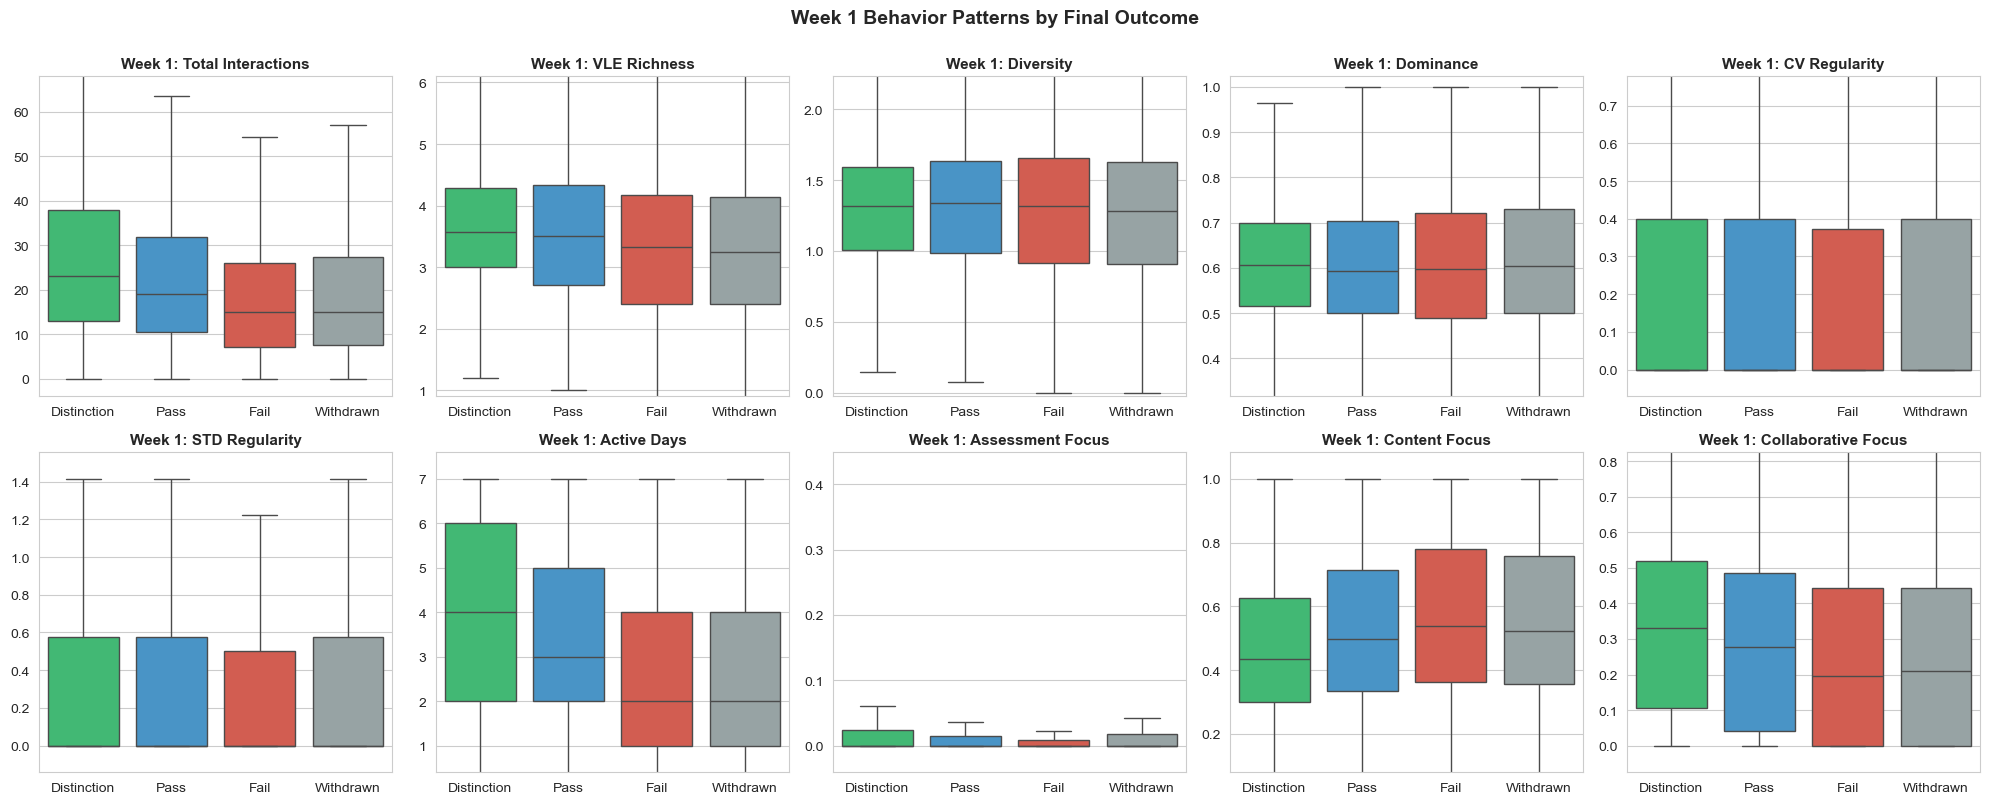


3. STATISTICAL SIGNIFICANCE (Can Week 1 predict outcomes?)
--------------------------------------------------------------------------------
            Feature p-value Sig Variance Explained Predictive?
 Total Interactions  0.0000 ***               1.5%         Yes
       VLE Richness  0.0000 ***               0.5%         Yes
          Diversity  0.0000 ***               0.3%         Yes
          Dominance  0.0000 ***               0.1%         Yes
      CV Regularity  0.0000 ***               0.1%         Yes
     STD Regularity  0.0001 ***               0.1%         Yes
        Active Days  0.0000 ***               4.2%         Yes
   Assessment Focus  0.0000 ***               0.4%         Yes
      Content Focus  0.0000 ***               1.2%         Yes
Collaborative Focus  0.0000 ***               1.1%         Yes

4. KEY TAKEAWAY

10 out of 10 Week 1 features significantly predict outcomes:

Top predictors (highest variance explained):
  • Active Days: 4.2% of outcome variatio

In [49]:
# Define features to analyze
week1_features = [
    'total_vle_interactions_w1', 'vle_richness_w1', 'diversity_shannon_w1', 
    'dominance_w1', 'cv_regularity_w1', 'std_regularity_w1', 'active_days_w1',
    'assessment_focus_ratio_w1', 'content_focus_ratio_w1', 'collaborative_focus_ratio_w1'
]

print("=" * 80)
print("WEEK 1 BEHAVIOR AS PREDICTOR OF STUDENT OUTCOMES")
print("=" * 80)

# 1. SUMMARY: Average values by outcome
print("\n1. AVERAGE WEEK 1 METRICS BY FINAL RESULT")
print("-" * 80)
summary = week_one.groupby('final_result')[week1_features].mean().round(3)
print(summary.T)  # Transpose for easier reading

# 2. VISUALIZATIONS (with better outlier handling)
print("\n2. Creating visualizations...")

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

result_order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']

feature_labels = {
    'total_vle_interactions_w1': 'Total Interactions',
    'vle_richness_w1': 'VLE Richness',
    'diversity_shannon_w1': 'Diversity',
    'dominance_w1': 'Dominance',
    'cv_regularity_w1': 'CV Regularity',
    'std_regularity_w1': 'STD Regularity',
    'active_days_w1': 'Active Days',
    'assessment_focus_ratio_w1': 'Assessment Focus',
    'content_focus_ratio_w1': 'Content Focus',
    'collaborative_focus_ratio_w1': 'Collaborative Focus'
}

for idx, feature in enumerate(week1_features):
    # Create box plot with modified outlier display
    sns.boxplot(data=week_one, x='final_result', y=feature,
                order=result_order, palette=colors, ax=axes[idx],
                showfliers=False)  # Hide extreme outliers
    
    # Set y-axis limits based on 5th and 95th percentiles to focus on main distribution
    q05 = week_one[feature].quantile(0.05)
    q95 = week_one[feature].quantile(0.95)
    margin = (q95 - q05) * 0.1  # Add 10% margin
    axes[idx].set_ylim(q05 - margin, q95 + margin)
    
    axes[idx].set_title(f'Week 1: {feature_labels[feature]}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')

plt.suptitle('Week 1 Behavior Patterns by Final Outcome', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# 3. STATISTICAL TESTS
print("\n3. STATISTICAL SIGNIFICANCE (Can Week 1 predict outcomes?)")
print("-" * 80)

results = []
for feature in week1_features:
    # Get groups
    groups = [week_one[week_one['final_result'] == r][feature].dropna() 
              for r in result_order]
    
    # ANOVA test
    f_stat, p_value = stats.f_oneway(*groups)
    
    # Effect size (eta-squared)
    all_data = pd.concat(groups)
    grand_mean = all_data.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total = sum((x - grand_mean)**2 for g in groups for x in g)
    eta_squared = ss_between / ss_total if ss_total > 0 else 0
    
    # Determine significance
    sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    
    results.append({
        'Feature': feature_labels[feature],
        'p-value': f'{p_value:.4f}',
        'Sig': sig,
        'Eta_Squared': eta_squared,
        'Variance Explained': f'{eta_squared*100:.1f}%',
        'Predictive?': 'Yes' if p_value < 0.05 else 'No'
    })

results_df = pd.DataFrame(results)
print(results_df[['Feature', 'p-value', 'Sig', 'Variance Explained', 'Predictive?']].to_string(index=False))

# 4. KEY INSIGHTS
print("\n" + "=" * 80)
print("4. KEY TAKEAWAY")
print("=" * 80)

significant_features = results_df[results_df['Predictive?'] == 'Yes']
print(f"\n{len(significant_features)} out of {len(week1_features)} Week 1 features significantly predict outcomes:")

print("\nTop predictors (highest variance explained):")
top3 = results_df.nlargest(5, 'Eta_Squared')
for idx, row in top3.iterrows():
    print(f"  • {row['Feature']}: {row['Variance Explained']} of outcome variation")
